# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 05: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_06_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

O dataset pertence ao domínio de negócios em telecomunicações e foi coletado aleatoriamente a partir de uma base de uma empresa iraniana da área ao longo de 12 meses. O objetivo do dataset é apoiar tarefas de classificação binária, como previsão de evasão de clientes. A base contem 3150 instâncias, cada uma representando um cliente, com 13 atributos preditores e sem valores ausentes, incluindo informações de falhas de chamadas, reclamações, tempo de assinatura, valor de recarga, segundos de uso, frequência de chamadas, frequência de SMS, quantidade de números distintos chamados, grupo de idade, plano tarifário, status do cliente e valor calculado do cliente.

In [4]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [5]:
display(df.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [10]:
print("Dimensões do dataframe:", df.shape)

TARGET_COLUMN = ds.data.targets.columns[0]

print("Variável alvo:", TARGET_COLUMN)
print("Valores únicos da variável alvo:", df[TARGET_COLUMN].unique())

Dimensões do dataframe: (3150, 14)
Variável alvo: Churn
Valores únicos da variável alvo: [0 1]


In [7]:
TARGET_COLUMN = "Churn"

O dataframe possui 3150 amostras e 14 colunas no total, sendo 13 atributos preditores e 1 variável alvo. A variável alvo é Churn. O problema é de classificação binária, pois Churn possui apenas dois valores únicos: 0 e 1

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [11]:
target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_props = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "Quantidade": target_counts,
    "Proporção (%)": target_props.round(2)
}))

,Quantidade,Proporção (%)
Churn,,
0,2655,84.29
1,495,15.71


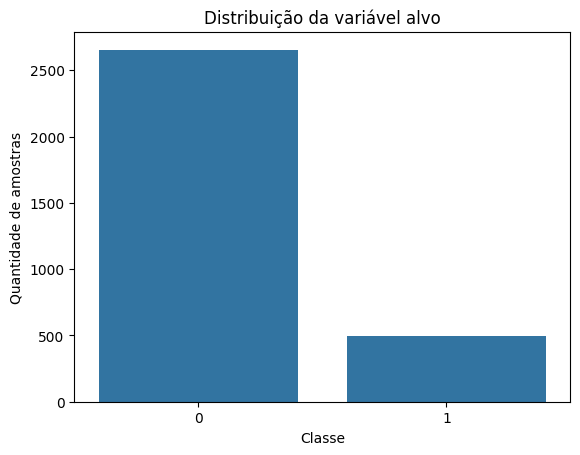

In [9]:
sns.countplot(data=df, x=TARGET_COLUMN)
plt.title("Distribuição da variável alvo")
plt.xlabel("Classe")
plt.ylabel("Quantidade de amostras")
plt.show()

O dataset é desbalanceado, pois a classe 0 possui 2655 amostras, 84,29% do total, enquanto a classe 1 possui apenas 495 amostras, 15,71%. Portanto, há predominância da classe 0.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

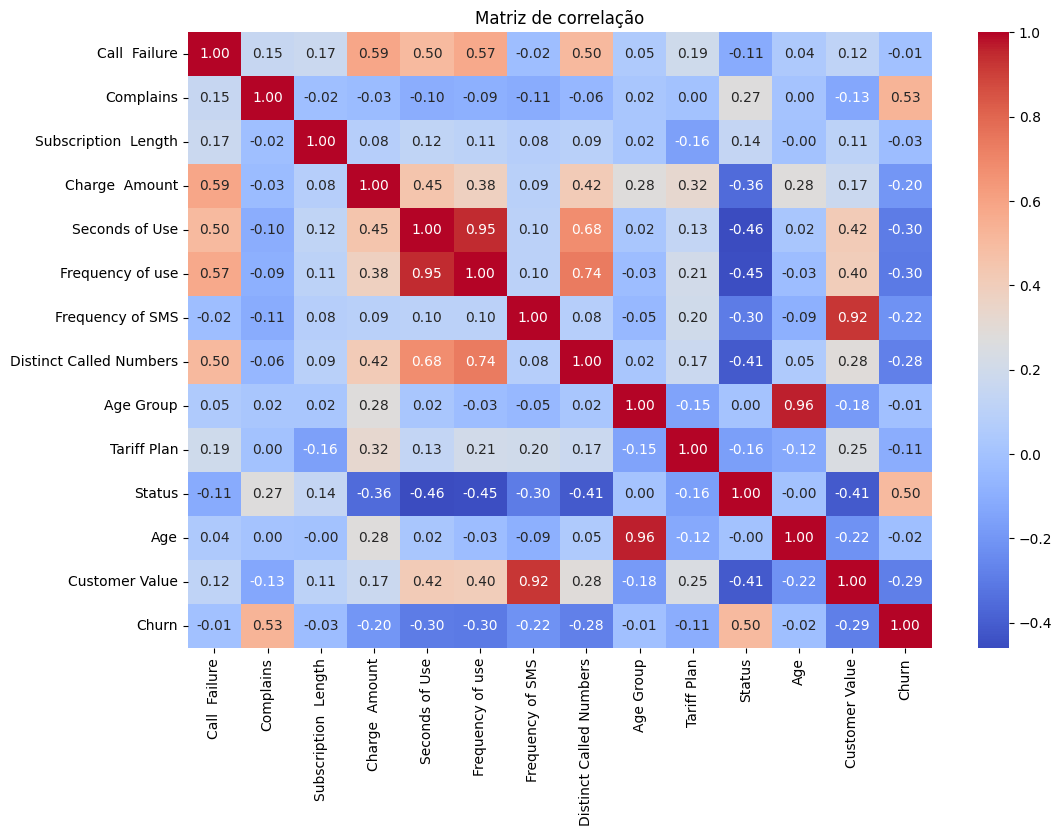

In [12]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação")
plt.show()

In [13]:
target_corr = corr_matrix[[TARGET_COLUMN]].sort_values(
    by=TARGET_COLUMN,
    ascending=False
)

display(target_corr)

,Churn
Churn,1.000000
Complains,0.532053
Status,0.498976
Call Failure,-0.008987
Age Group,-0.014550
Age,-0.017705
Subscription Length,-0.032588
Tariff Plan,-0.105853
Charge Amount,-0.202305
Frequency of SMS,-0.220754


Os atributos com maior correlação positiva com Churn são Complains (0.53) e Status (0.50), indicando maior associação com a evasão. As maiores correlações negativas são Frequency of use (-0.30), Seconds of Use (-0.30), Customer Value (-0.29) e Distinct Called Numbers (-0.28). Assim, esses atributos podem ser mais relevantes para o problema de classificação.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

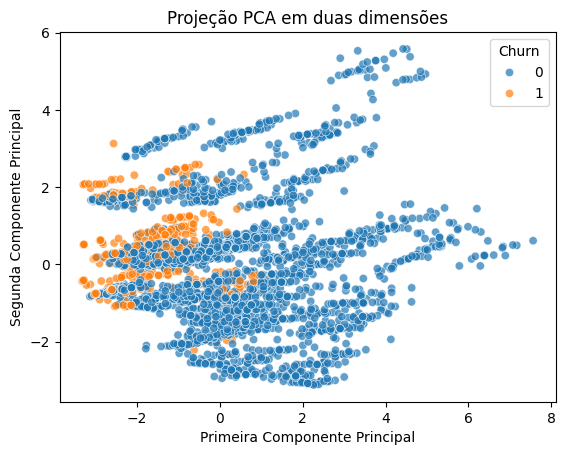

Variância explicada: [0.30904449 0.17841786]
Variância explicada acumulada: 0.4874623541704386


In [14]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df[TARGET_COLUMN] = y.values

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=TARGET_COLUMN, alpha=0.7)
plt.title("Projeção PCA em duas dimensões")
plt.xlabel("Primeira Componente Principal")
plt.ylabel("Segunda Componente Principal")
plt.show()

print("Variância explicada:", pca.explained_variance_ratio_)
print("Variância explicada acumulada:", pca.explained_variance_ratio_.sum())

Pela projeção em duas dimensões, não há separação clara entre as classes. Os pontos das classes 0 e 1 aparecem com sobreposição significativa, indicando que as duas primeiras componentes principais não isolam bem os clientes churn e não churn.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [15]:
features = df.columns.drop(TARGET_COLUMN)

X = df[features]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Treino: (2520, 13) (2520,)
Teste: (630, 13) (630,)


A padronização é importante porque coloca os atributos em uma escala comparável, com média zero e desvio padrão unitário, evitando que variáveis com valores maiores dominem o treinamento do modelo. O fit deve ser aplicado apenas no conjunto de treino porque ele calcula média e desvio padrão; se fosse ajustado usando também o teste, haveria vazamento de informação do teste para o treinamento.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [17]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

print("Número de iterações:", model.n_iter_[0])
print("Convergiu:", model.n_iter_[0] < model.max_iter)

Número de iterações: 42
Convergiu: True


A regressão logística atua como um classificador binário para prever se um cliente pertence à classe 0 ou 1. O modelo aprende, a partir dos dados de treino, os pesos associados a cada atributo para estimar a probabilidade de uma amostra pertencer à classe positiva. O treinamento busca ajustar esses pesos minimizando o erro de classificação por meio de uma função de perda.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [19]:
y_proba = model.predict_proba(X_test_scaled)

proba_df = pd.DataFrame(
    y_proba,
    columns=[f"P({TARGET_COLUMN}={classe})" for classe in model.classes_]
)

proba_df["Classe prevista"] = model.predict(X_test_scaled)
proba_df["Confiança"] = y_proba.max(axis=1)

display(proba_df.head(10))

,P(Churn=0),P(Churn=1),Classe prevista,Confiança
0,0.998819,0.001181,0,0.998819
1,0.999954,0.000046,0,0.999954
2,0.974259,0.025741,0,0.974259
3,0.999518,0.000482,0,0.999518
4,0.998645,0.001355,0,0.998645
5,0.997155,0.002845,0,0.997155
6,0.991459,0.008541,0,0.991459
7,0.991455,0.008545,0,0.991455
8,0.987025,0.012975,0,0.987025
9,0.590190,0.409810,0,0.590190


Cada linha representa uma amostra do conjunto de teste. A coluna P(Churn=0) indica a probabilidade estimada de o cliente não cancelar, enquanto P(Churn=1) indica a probabilidade estimada de churn. A classe prevista é aquela com maior probabilidade. Valores próximos de 1 indicam alta confiança; valores próximos de 0,5 indicam maior incerteza

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [20]:
positive_idx = np.where(model.classes_ == 1)[0][0]
y_score = y_proba[:, positive_idx]

results = []

for threshold in [0.5, 0.7]:
    y_pred_thr = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()

    results.append({
        "Limiar": threshold,
        "Previstos como 0": (y_pred_thr == 0).sum(),
        "Previstos como 1": (y_pred_thr == 1).sum(),
        "VN": tn,
        "FP": fp,
        "FN": fn,
        "VP": tp
    })

threshold_results = pd.DataFrame(results)
display(threshold_results)

,Limiar,Previstos como 0,Previstos como 1,VN,FP,FN,VP
0,0.5,570,60,504,16,66,44
1,0.7,588,42,514,6,74,36


Ao aumentar o limiar de 0.5 para 0.7, o modelo fica mais exigente para classificar um cliente como Churn = 1. Assim, a tendência é reduzir a quantidade de previsões positivas, diminuindo os falsos positivos, mas aumentando os falsos negativos, pois alguns clientes que realmente deram churn podem deixar de ser identificados. Portanto, o limiar 0.5 é mais permissivo, enquanto o limiar 0.7 prioriza maior confiança para prever a classe positiva.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

,Limiar,Acurácia,Precisão,Recall,F1-score
0,0.5,0.869841,0.733333,0.400000,0.517647
1,0.7,0.873016,0.857143,0.327273,0.473684


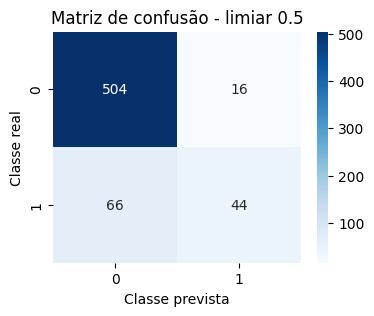

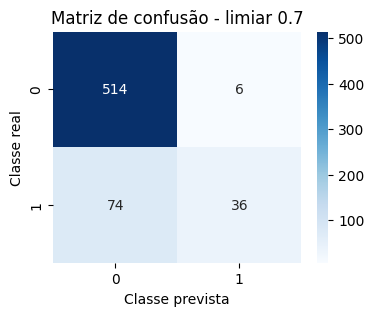

In [21]:
def avaliar_limiar(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)

    return {
        "Limiar": threshold,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

metricas = pd.DataFrame([
    avaliar_limiar(y_test, y_score, 0.5),
    avaliar_limiar(y_test, y_score, 0.7)
])

display(metricas)

for threshold in [0.5, 0.7]:
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de confusão - limiar {threshold}")
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.show()

Ao aumentar o limiar de 0.5 para 0.7, o modelo passa a prever menos casos como Churn = 1. Com isso, a precisão tende a aumentar, pois as previsões positivas restantes são mais confiáveis, enquanto o recall tende a diminuir, pois mais clientes que realmente deram churn deixam de ser identificados. Assim, a métrica mais impactada pela mudança do limiar costuma ser o recall.

O trade-off observado é: limiar menor detecta mais churns, mas gera mais falsos positivos; limiar maior reduz falsos positivos, mas aumenta falsos negativos.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

In [ ]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [ ]:
TARGET_COLUMN = None # preencher

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>